In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [2]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5, n_clusters_per_class=1)

In [3]:
df = pd.DataFrame(X, columns=['col1','col2','col3','col4','col5'])
df['target']=y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-0.703084,1.668718,-1.942332,-1.073127,2.454799,0
1,2.848454,4.699008,-0.608378,0.590461,3.804208,1
2,-0.061872,0.404592,-1.447939,-2.406597,-0.450026,1
3,1.003000,1.659722,-1.537490,-1.378019,1.023559,1
4,-0.447374,-1.141459,-1.996727,-2.526814,3.314207,0


In [4]:
def sample_features(df,percent):
    cols = random.sample(df.columns.tolist()[:-1],int(percent*df.shape[1]))
    return df[cols]

In [5]:
def sample_rows(df,percent):
    return df.sample(int(percent*df.shape[0]),replace=True)

In [6]:
def combined_sampling(df,row_percent,col_percent):
    new_df = sample_rows(df,row_percent)
    return sample_features(new_df,col_percent)

In [7]:
df1 = sample_rows(df,0.2)

In [8]:
df2 = sample_rows(df,0.2)

In [9]:
df2

,col1,col2,col3,col4,col5,target
9,-0.099777,-0.289847,-0.097330,-2.198811,-1.170935,1
98,0.563093,0.652199,-1.037109,-1.729873,0.003536,1
76,3.451870,2.418361,-1.498325,1.457190,3.873984,1
13,1.576916,1.414880,-2.922903,-0.677864,2.253396,1
54,0.832107,3.578416,1.415198,-1.574647,0.386905,1
84,-0.583452,-1.159137,-2.977821,-0.615580,1.843954,0
76,3.451870,2.418361,-1.498325,1.457190,3.873984,1
46,0.624938,1.788063,0.450925,-1.575568,0.080239,1
34,-1.194468,4.020682,-1.049599,-3.186463,0.432405,0
39,-2.028559,0.501546,-0.300966,-1.057300,0.090577,0


In [10]:
df3 = sample_rows(df, 0.2)

In [11]:
df3

,col1,col2,col3,col4,col5,target
83,0.254949,-0.538537,-2.513163,-2.102064,-0.200370,1
59,2.834313,5.195170,-0.115564,-0.717719,1.668738,1
1,2.848454,4.699008,-0.608378,0.590461,3.804208,1
43,0.359789,0.281148,-0.183324,-0.280397,2.792865,0
26,-1.520071,0.180791,-0.936729,0.526935,0.211404,0
20,-0.507387,0.160685,3.163682,-0.795353,0.044803,1
87,1.995940,2.386420,-2.126307,-0.508324,2.284269,1
67,0.614192,1.946140,-0.284938,-0.245241,2.791814,0
69,-0.956155,-0.316558,-0.940992,-0.981997,0.052021,0
46,0.624938,1.788063,0.450925,-1.575568,0.080239,1


In [12]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [13]:
clf1.fit(df1.iloc[:,0:5], df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:5], df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:5], df3.iloc[:,-1])

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [14]:
from sklearn.tree import plot_tree

[Text(0.5, 0.9, 'x[0] <= 0.589\ngini = 0.5\nsamples = 20\nvalue = [10, 10]'),
 Text(0.25, 0.7, 'x[3] <= -1.886\ngini = 0.298\nsamples = 11\nvalue = [9, 2]'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.375, 0.5, 'x[1] <= -1.109\ngini = 0.18\nsamples = 10\nvalue = [9, 1]'),
 Text(0.25, 0.3, 'x[2] <= -0.94\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.125, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.375, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.5, 0.3, 'gini = 0.0\nsamples = 8\nvalue = [8, 0]'),
 Text(0.75, 0.7, 'x[3] <= -2.031\ngini = 0.198\nsamples = 9\nvalue = [1, 8]'),
 Text(0.625, 0.8, '  False'),
 Text(0.625, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.875, 0.5, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]')]

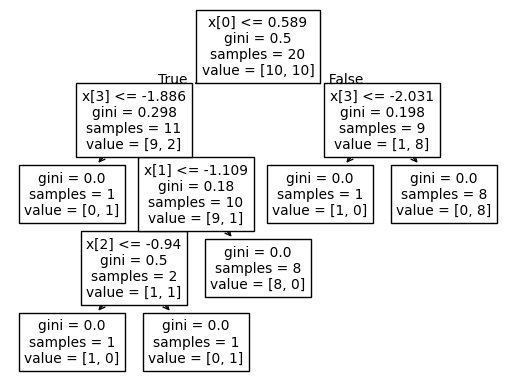

In [15]:
plot_tree(clf1)

[Text(0.4, 0.8333333333333334, 'x[0] <= -0.342\ngini = 0.455\nsamples = 20\nvalue = [7, 13]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[1] <= -0.695\ngini = 0.133\nsamples = 14\nvalue = [1, 13]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 13\nvalue = [0, 13]')]

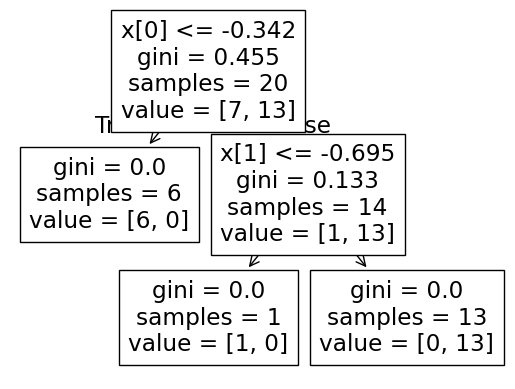

In [16]:
plot_tree(clf2)

[Text(0.4, 0.8333333333333334, 'x[0] <= -0.342\ngini = 0.455\nsamples = 20\nvalue = [7, 13]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[1] <= -0.695\ngini = 0.133\nsamples = 14\nvalue = [1, 13]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 13\nvalue = [0, 13]')]

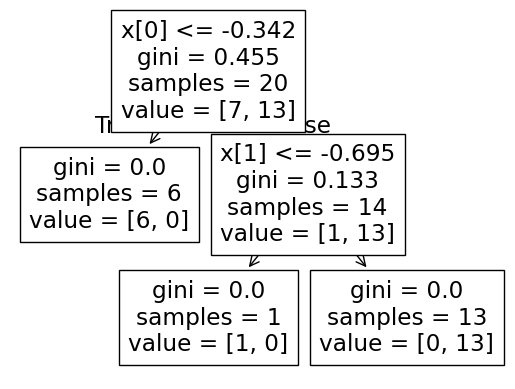

In [17]:
plot_tree(clf2)

In [18]:
clf1.predict(np.array([0.551300,-1.876815,-1.807618,-1.557932,-0.039809]).reshape(1,5))

C:\Users\HP\anaconda3\envs\st_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [19]:
clf2.predict(np.array([0.551300,-1.876815,-1.807618,-1.557932,-0.039809]).reshape(1,5))

C:\Users\HP\anaconda3\envs\st_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [20]:
clf3.predict(np.array([0.551300,-1.876815,-1.807618,-1.557932,-0.039809]).reshape(1,5))

C:\Users\HP\anaconda3\envs\st_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

class sklearn.ensemble.RandomForestClassifier(n_estimators=100, *, criterion='gini', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features='sqrt', max_leaf_nodes=None, min_impurity_decrease=0.0, bootstrap=True, oob_score=False, n_jobs=None, random_state=None, verbose=0, warm_start=False, class_weight=None, ccp_alpha=0.0, max_samples=None, monotonic_cst=None)

- Some of these are to train random forest and some train decision tree


- n_estimators : how many dt are used to make this rf

- max_features : how many columns are used to split the node

- Bootstrap : do we use repeated values or not

- max_sample : rows given to each dt (50-75 is optimal range)

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

In [23]:
df = pd.read_csv('Datasets/heart.csv')

In [24]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [25]:
df.shape

(1025, 14)

In [26]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [27]:
X.shape, y.shape

((1025, 13), (1025,))

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [29]:
X_train.shape, X_test.shape

((820, 13), (205, 13))

In [30]:
y_train.shape, y_test.shape

((820,), (205,))

In [68]:
rf = RandomForestClassifier()

In [69]:
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.9853658536585366

In [70]:
rf = RandomForestClassifier(max_samples=0.75, random_state=42)
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy2 = accuracy_score(y_test, y_pred)
accuracy2

0.9853658536585366

In [35]:
from sklearn.model_selection import cross_val_score
np.mean(cross_val_score(RandomForestClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.9970588235294118)

In [38]:
from sklearn.metrics import confusion_matrix, classification_report

In [39]:
confusion_matrix(y_test,y_pred)

array([[102,   0],
       [  3, 100]])

In [40]:
classification_report(y_test,y_pred)

'              precision    recall  f1-score   support\n\n           0       0.97      1.00      0.99       102\n           1       1.00      0.97      0.99       103\n\n    accuracy                           0.99       205\n   macro avg       0.99      0.99      0.99       205\nweighted avg       0.99      0.99      0.99       205\n'

- How to know which value to give to a parameter of rf

- we have 2 methods for it:
    - GridSearchCV
    - RandomSearchCV

### GridSearchCV

In [41]:
n_estimators=[20,60,100,120]
max_depth=[2,8,None]
max_features=[0.2,0.6,1.0]
max_samples=[0.5,0.75,1.0]

In [42]:
params = {
    'n_estimators':n_estimators,
    'max_features':max_features,
    'max_depth':max_depth,
    'max_samples':max_samples
}

In [43]:
params

{'n_estimators': [20, 60, 100, 120],
 'max_features': [0.2, 0.6, 1.0],
 'max_depth': [2, 8, None],
 'max_samples': [0.5, 0.75, 1.0]}

In [44]:
rf = RandomForestClassifier()

In [45]:
from sklearn.model_selection import GridSearchCV

In [46]:
rf_grid = GridSearchCV(estimator=rf,
                      param_grid=params,
                      cv=5,
                      verbose=2,
                      n_jobs=-1)

In [47]:
rf_grid.fit(X_train,y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


,estimator,RandomForestClassifier()
,param_grid,"{'max_depth': [2, 8, ...], 'max_features': [0.2, 0.6, ...], 'max_samples': [0.5, 0.75, ...], 'n_estimators': [20, 60, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,20


In [48]:
rf_grid.best_params_

{'max_depth': None,
 'max_features': 0.2,
 'max_samples': 1.0,
 'n_estimators': 20}

In [49]:
rf_grid.best_score_

np.float64(0.9865853658536585)

### RandomSearchCV

In [59]:
bootstrap = [True,False]
min_samples_split = [2,5]
min_samples_leaf = [1,2]

In [60]:
param_random = {
    'n_estimators':n_estimators,
    'max_features':max_features,
    'max_depth':max_depth,
    'max_samples':max_samples,
    'bootstrap':bootstrap,
    'min_samples_split':min_samples_split,
    'min_samples_leaf':min_samples_leaf
}

In [61]:
param_random

{'n_estimators': [20, 60, 100, 120],
 'max_features': [0.2, 0.6, 1.0],
 'max_depth': [2, 8, None],
 'max_samples': [0.5, 0.75, 1.0],
 'bootstrap': [True, False],
 'min_samples_split': [2, 5],
 'min_samples_leaf': [1, 2]}

In [62]:
from sklearn.model_selection import RandomizedSearchCV

In [63]:
rf_random = RandomizedSearchCV(estimator=rf,
                      param_distributions=param_random,
                      cv=5,
                      verbose=2,
                      n_jobs=-1)

In [64]:
rf_random.fit(X_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


C:\Users\HP\anaconda3\envs\st_env\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
30 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\HP\anaconda3\envs\st_env\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\HP\anaconda3\envs\st_env\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\HP\anaconda3\envs\st_env\lib\site-packages\sklearn\ensemble\_forest.py", line 430, in fit
    raise ValueError(
ValueError: `

,estimator,RandomForestClassifier()
,param_distributions,"{'bootstrap': [True, False], 'max_depth': [2, 8, ...], 'max_features': [0.2, 0.6, ...], 'max_samples': [0.5, 0.75, ...], ...}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [65]:
rf_random.best_params_

{'n_estimators': 120,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_samples': 1.0,
 'max_features': 0.2,
 'max_depth': None,
 'bootstrap': True}

In [66]:
rf_random.best_score_

np.float64(0.9743902439024389)

- use random when we have huge amount of data

In [71]:
rf.feature_importances_

array([0.08669254, 0.02776889, 0.13003347, 0.06917774, 0.08121702,
       0.00970675, 0.01765972, 0.11986792, 0.05305226, 0.11768695,
       0.05028614, 0.1233647 , 0.11348589])

<Axes: >

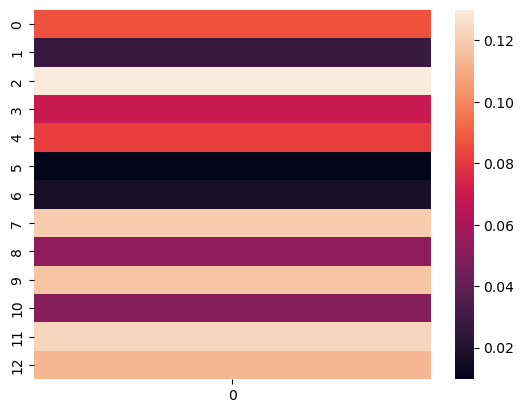

In [75]:
sns.heatmap(rf.feature_importances_.reshape(13,1))

<Axes: >

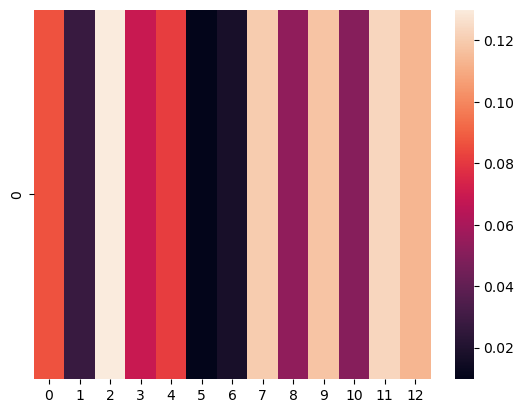

In [80]:
sns.heatmap(rf.feature_importances_.reshape(1,13))

In [77]:
rf.feature_names_in_

array(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
       'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal'], dtype=object)